<a href="https://colab.research.google.com/github/aniray2908/nlp-llm-journey/blob/main/01_nlp_fundamentals/demos/05_language_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Imports & Setup**

In [1]:
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math

**Cell 2 — Load and Prepare Text**

In [2]:
# Use a simple text corpus
text = """
The cat sat on the mat. The dog played in the park.
Cats are cute and fluffy. Dogs love to play fetch.
The quick brown fox jumps over the lazy dog.
A cat and a dog became friends. They played together.
The cat sat on the mat and looked out the window.
Dogs bark when they hear a sound. Cats meow softly.
The fox was quick and clever. The dog was loyal.
""".lower().replace('.', '').replace(',', '')

# Tokenise into words
words = text.split()
print(f"Corpus size: {len(words)} words")
print(f"Unique words: {len(set(words))} unique tokens")
print(f"First 20 words: {words[:20]}")

Corpus size: 72 words
Unique words: 42 unique tokens
First 20 words: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the', 'dog', 'played', 'in', 'the', 'park', 'cats', 'are', 'cute', 'and', 'fluffy', 'dogs', 'love', 'to']


**Cell 3 — Unigram Model (Baseline)**

In [3]:
# Count word frequencies
unigram_counts = Counter(words)
total_words = len(words)

# Convert to probabilities
unigram_probs = {word: count / total_words for word, count in unigram_counts.items()}

print("Unigram probabilities (top 10):")
for word, prob in sorted(unigram_probs.items(), key=lambda x: -x[1])[:10]:
    print(f"  P({word}) = {prob:.3f}")

# Perplexity of unigram model
def compute_perplexity(words, probs, model_name=""):
    """Compute perplexity given word probabilities."""
    log_probs = []
    oov_count = 0

    for word in words:
        if word in probs:
            log_probs.append(math.log(probs[word]))
        else:
            oov_count += 1
            log_probs.append(math.log(1e-9))  # smoothing for OOV

    cross_entropy = -sum(log_probs) / len(words)
    perplexity = math.exp(cross_entropy)

    print(f"\n{model_name}")
    print(f"  Cross-entropy: {cross_entropy:.3f}")
    print(f"  Perplexity: {perplexity:.1f}")
    print(f"  OOV words: {oov_count}")

    return perplexity

perp_unigram = compute_perplexity(words, unigram_probs, "Unigram model")

Unigram probabilities (top 10):
  P(the) = 0.153
  P(dog) = 0.056
  P(and) = 0.056
  P(cat) = 0.042
  P(a) = 0.042
  P(sat) = 0.028
  P(on) = 0.028
  P(mat) = 0.028
  P(played) = 0.028
  P(cats) = 0.028

Unigram model
  Cross-entropy: 3.472
  Perplexity: 32.2
  OOV words: 0


**Cell 4 — Bigram Model**

In [4]:
# Build bigram counts
bigram_counts = defaultdict(Counter)
for i in range(len(words) - 1):
    context = words[i]
    next_word = words[i + 1]
    bigram_counts[context][next_word] += 1

# Convert to conditional probabilities P(next_word | context)
bigram_probs = {}
for context, counts in bigram_counts.items():
    total = sum(counts.values())
    bigram_probs[context] = {word: count / total for word, count in counts.items()}

print("Bigram probabilities (given 'the'):")
if 'the' in bigram_probs:
    for word, prob in sorted(bigram_probs['the'].items(), key=lambda x: -x[1])[:5]:
        print(f"  P({word} | the) = {prob:.3f}")

print("\nBigram probabilities (given 'cat'):")
if 'cat' in bigram_probs:
    for word, prob in sorted(bigram_probs['cat'].items(), key=lambda x: -x[1])[:5]:
        print(f"  P({word} | cat) = {prob:.3f}")

Bigram probabilities (given 'the'):
  P(cat | the) = 0.182
  P(mat | the) = 0.182
  P(dog | the) = 0.182
  P(park | the) = 0.091
  P(quick | the) = 0.091

Bigram probabilities (given 'cat'):
  P(sat | cat) = 0.667
  P(and | cat) = 0.333


**Cell 5 — Perplexity Comparison**

In [5]:
def bigram_perplexity(words, bigram_probs, unigram_probs):
    """Compute perplexity using bigram model with backoff."""
    log_probs = []
    oov_count = 0

    for i in range(len(words) - 1):
        context = words[i]
        next_word = words[i + 1]

        if context in bigram_probs and next_word in bigram_probs[context]:
            prob = bigram_probs[context][next_word]
        else:
            # Backoff to unigram if bigram not found
            prob = unigram_probs.get(next_word, 1e-9)
            oov_count += 1

        log_probs.append(math.log(prob))

    cross_entropy = -sum(log_probs) / len(log_probs)
    perplexity = math.exp(cross_entropy)

    print(f"\nBigram model (with backoff)")
    print(f"  Cross-entropy: {cross_entropy:.3f}")
    print(f"  Perplexity: {perplexity:.1f}")
    print(f"  OOV bigrams: {oov_count}")

    return perplexity

perp_bigram = bigram_perplexity(words, bigram_probs, unigram_probs)

print(f"\n{'='*50}")
print(f"Improvement: {perp_unigram / perp_bigram:.1f}x better with bigrams")


Bigram model (with backoff)
  Cross-entropy: 0.699
  Perplexity: 2.0
  OOV bigrams: 0

Improvement: 16.0x better with bigrams


**Cell 6 — Trigram Model**

In [6]:
# Build trigram counts
trigram_counts = defaultdict(Counter)
for i in range(len(words) - 2):
    context = (words[i], words[i + 1])
    next_word = words[i + 2]
    trigram_counts[context][next_word] += 1

# Convert to probabilities
trigram_probs = {}
for context, counts in trigram_counts.items():
    total = sum(counts.values())
    trigram_probs[context] = {word: count / total for word, count in counts.items()}

print("Trigram probabilities (given 'the', 'cat'):")
if ('the', 'cat') in trigram_probs:
    for word, prob in sorted(trigram_probs[('the', 'cat')].items(), key=lambda x: -x[1])[:5]:
        print(f"  P({word} | the cat) = {prob:.3f}")

def trigram_perplexity(words, trigram_probs, bigram_probs, unigram_probs):
    """Compute perplexity using trigram model with backoff."""
    log_probs = []
    oov_count = 0

    for i in range(len(words) - 2):
        context = (words[i], words[i + 1])
        next_word = words[i + 2]

        if context in trigram_probs and next_word in trigram_probs[context]:
            prob = trigram_probs[context][next_word]
        elif words[i + 1] in bigram_probs and next_word in bigram_probs[words[i + 1]]:
            prob = bigram_probs[words[i + 1]][next_word]
        else:
            prob = unigram_probs.get(next_word, 1e-9)
            oov_count += 1

        log_probs.append(math.log(prob))

    cross_entropy = -sum(log_probs) / len(log_probs)
    perplexity = math.exp(cross_entropy)

    print(f"\nTrigram model (with backoff)")
    print(f"  Cross-entropy: {cross_entropy:.3f}")
    print(f"  Perplexity: {perplexity:.1f}")
    print(f"  OOV trigrams: {oov_count}")

    return perplexity

perp_trigram = trigram_perplexity(words, trigram_probs, bigram_probs, unigram_probs)

Trigram probabilities (given 'the', 'cat'):
  P(sat | the cat) = 1.000

Trigram model (with backoff)
  Cross-entropy: 0.040
  Perplexity: 1.0
  OOV trigrams: 0


**Cell 7 — Plot Perplexity Improvement**

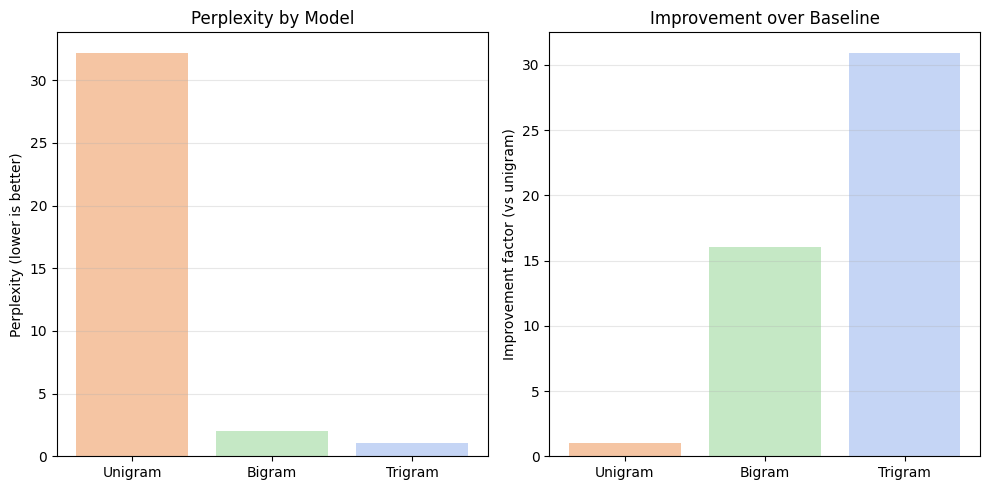

Unigram perplexity: 32.2
Bigram perplexity: 2.0 (16.0x improvement)
Trigram perplexity: 1.0 (31.0x improvement)


In [7]:
models = ['Unigram', 'Bigram', 'Trigram']
perplexities = [perp_unigram, perp_bigram, perp_trigram]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(models, perplexities, color=['#f5c5a3', '#c5e8c5', '#c5d5f5'])
plt.ylabel('Perplexity (lower is better)')
plt.title('Perplexity by Model')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
improvements = [1, perp_unigram / perp_bigram, perp_unigram / perp_trigram]
plt.bar(models, improvements, color=['#f5c5a3', '#c5e8c5', '#c5d5f5'])
plt.ylabel('Improvement factor (vs unigram)')
plt.title('Improvement over Baseline')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Unigram perplexity: {perp_unigram:.1f}")
print(f"Bigram perplexity: {perp_bigram:.1f} ({perp_unigram/perp_bigram:.1f}x improvement)")
print(f"Trigram perplexity: {perp_trigram:.1f} ({perp_unigram/perp_trigram:.1f}x improvement)")

**Cell 8 — Text Generation with n-grams**

In [8]:
import random

def generate_text_bigram(start_word, length=10):
    """Generate text using bigram model."""
    words_generated = [start_word]

    for _ in range(length - 1):
        current = words_generated[-1]

        if current in bigram_probs and bigram_probs[current]:
            # Sample next word based on probabilities
            next_words = list(bigram_probs[current].keys())
            next_probs = list(bigram_probs[current].values())
            next_word = np.random.choice(next_words, p=next_probs)
            words_generated.append(next_word)
        else:
            break

    return ' '.join(words_generated)

print("Bigram text generation samples:\n")
for i in range(5):
    text = generate_text_bigram('the', length=8)
    print(f"  {text}")

print("\n")
for i in range(5):
    text = generate_text_bigram('cat', length=8)
    print(f"  {text}")

Bigram text generation samples:

  the park cats are cute and a sound
  the quick brown fox jumps over the lazy
  the cat sat on the mat the cat
  the mat the mat and clever the lazy
  the cat sat on the dog played together


  cat and looked out the mat and clever
  cat sat on the lazy dog was quick
  cat sat on the quick and fluffy dogs
  cat sat on the dog played together the
  cat and a sound cats meow softly the


**Cell 9 — The Sparsity Problem**

In [9]:
print(f"Corpus statistics:")
print(f"  Unique unigrams: {len(unigram_counts)}")
print(f"  Unique bigrams: {sum(len(c) for c in bigram_counts.values())}")
print(f"  Unique trigrams: {sum(len(c) for c in trigram_counts.values())}")

# Estimate for 4-grams, 5-grams
print(f"\nEstimated unique n-grams (if patterns held):")
print(f"  4-grams: ~{sum(len(c) for c in trigram_counts.values()) * 0.7:.0f}")
print(f"  5-grams: ~{sum(len(c) for c in trigram_counts.values()) * 0.3:.0f}")

print(f"\nProblem: vocabulary grows exponentially with n")
print(f"  Bigrams per unique unigram: {sum(len(c) for c in bigram_counts.values()) / len(unigram_counts):.1f}")
print(f"  Trigrams per unique bigram: {sum(len(c) for c in trigram_counts.values()) / sum(len(c) for c in bigram_counts.values()):.2f}")

print(f"\nWith our tiny corpus ({len(words)} words):")
print(f"  Most 4-grams appear only once (or not at all)")
print(f"  Can't generalize to unseen sequences")
print(f"\nThis is why neural language models were invented:")
print(f"  - Learn dense representations (embeddings)")
print(f"  - Share parameters across similar contexts")
print(f"  - Generalise to unseen sequences")

Corpus statistics:
  Unique unigrams: 42
  Unique bigrams: 65
  Unique trigrams: 66

Estimated unique n-grams (if patterns held):
  4-grams: ~46
  5-grams: ~20

Problem: vocabulary grows exponentially with n
  Bigrams per unique unigram: 1.5
  Trigrams per unique bigram: 1.02

With our tiny corpus (72 words):
  Most 4-grams appear only once (or not at all)
  Can't generalize to unseen sequences

This is why neural language models were invented:
  - Learn dense representations (embeddings)
  - Share parameters across similar contexts
  - Generalise to unseen sequences


**Cell 10 — Information Theory Intuition**

In [10]:
print("What does perplexity mean?\n")

print("Perplexity = exp(cross-entropy loss)")
print("Interpretation: average number of equally-likely choices\n")

print("Examples:")
print("  Perplexity = 1:   Perfect predictor (always 100% sure)")
print("  Perplexity = 2:   Model is certain between 2 equally likely words")
print("  Perplexity = 10:  Model is uncertain — 10 words seem equally likely")
print("  Perplexity = 50k: Model is confused — whole vocabulary seems equally likely\n")

print(f"Our models:")
print(f"  Unigram (perplexity {perp_unigram:.1f}):")
print(f"    → On average {perp_unigram:.1f} words seem equally plausible")
print(f"  Bigram (perplexity {perp_bigram:.1f}):")
print(f"    → On average {perp_bigram:.1f} words seem equally plausible")
print(f"  Trigram (perplexity {perp_trigram:.1f}):")
print(f"    → On average {perp_trigram:.1f} words seem equally plausible\n")

print(f"Real LLM numbers:")
print(f"  GPT-2: perplexity ≈ 24 on WikiText-103 test set")
print(f"  GPT-3: perplexity ≈ 20 on WikiText-103 test set")
print(f"  Our bigram: perplexity {perp_bigram:.1f} on toy corpus")
print(f"  → Much worse because: tiny corpus, tiny model, limited context")

What does perplexity mean?

Perplexity = exp(cross-entropy loss)
Interpretation: average number of equally-likely choices

Examples:
  Perplexity = 1:   Perfect predictor (always 100% sure)
  Perplexity = 2:   Model is certain between 2 equally likely words
  Perplexity = 10:  Model is uncertain — 10 words seem equally likely
  Perplexity = 50k: Model is confused — whole vocabulary seems equally likely

Our models:
  Unigram (perplexity 32.2):
    → On average 32.2 words seem equally plausible
  Bigram (perplexity 2.0):
    → On average 2.0 words seem equally plausible
  Trigram (perplexity 1.0):
    → On average 1.0 words seem equally plausible

Real LLM numbers:
  GPT-2: perplexity ≈ 24 on WikiText-103 test set
  GPT-3: perplexity ≈ 20 on WikiText-103 test set
  Our bigram: perplexity 2.0 on toy corpus
  → Much worse because: tiny corpus, tiny model, limited context
